<a href="https://colab.research.google.com/github/headdown0845/2026_First-semester/blob/main/260605_2355022_%EC%9D%B4%ED%98%95%EB%AF%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [ ]:
rng = np.random.RandomState(1234)
X = 10 * rng.rand(100); y = np.cos(X) + 0.25 * rng.randn(100)
Xfit = np.linspace(0, 10, 100)

In [ ]:
models = {
    'Linear': make_pipeline(LinearRegression()),
    'Polynomial': make_pipeline(PolynomialFeatures(20), LinearRegression()),
    'Ridge': make_pipeline(PolynomialFeatures(20), Ridge(alpha=1)),
    'Lasso': make_pipeline(PolynomialFeatures(20), Lasso(alpha=1)),
}

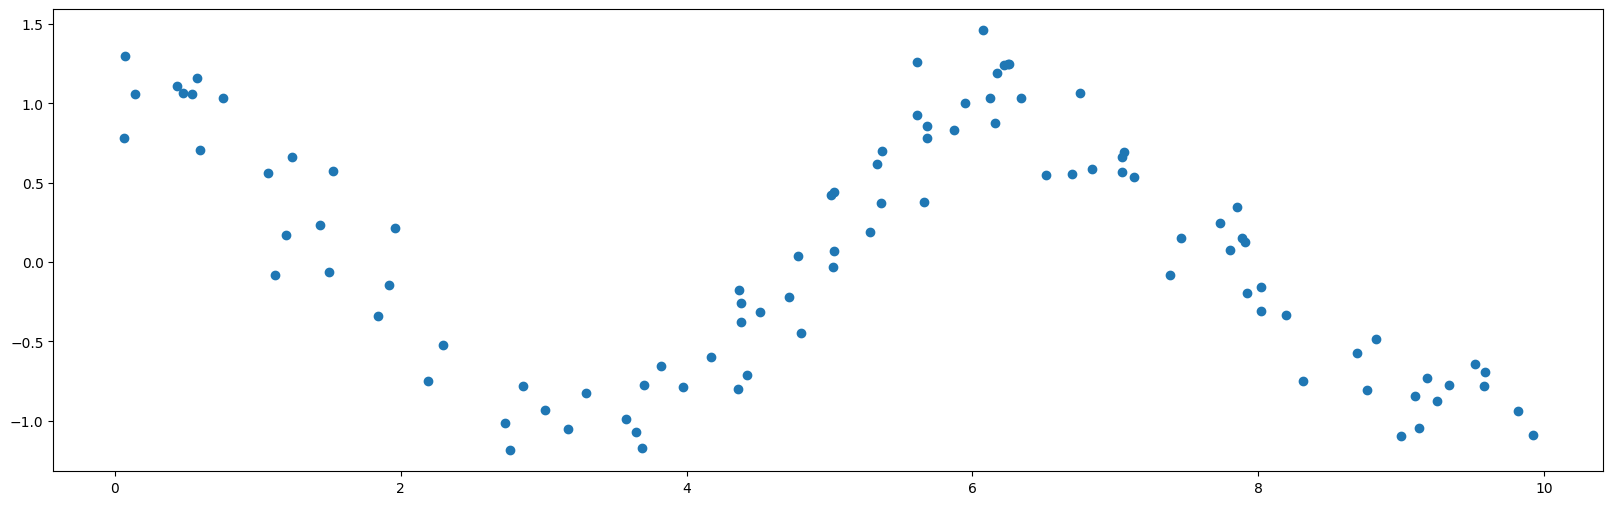

In [ ]:
plt.figure(figsize=(20, 6)); plt.scatter(X, y)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.848e+01, tolerance: 5.723e-03
  model = cd_fast.enet_coordinate_descent(


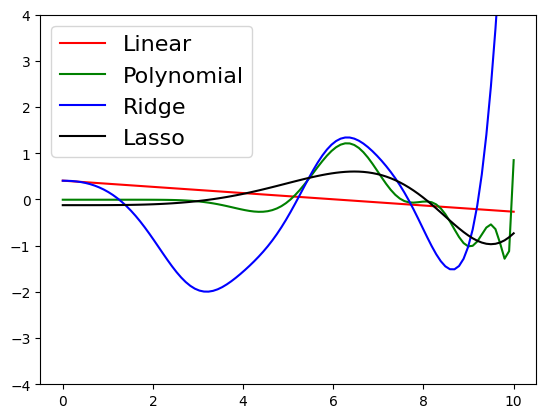

In [ ]:

styles = ['r-', 'g-', 'b-', 'k-']

for (name, model), style in zip(models.items(), styles):
     model.fit(X[:, np.newaxis], y)
     plt.plot(Xfit, model.predict(Xfit[:, np.newaxis]), style, label=name)
plt.legend(fontsize=16); plt.ylim(-4, 4)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures

In [ ]:

# 1. 테스트용 가상 데이터 생성 (10차 다항식 형태의 관계를 가진 데이터)
np.random.seed(42)
X = np.random.uniform(-2, 2, size=(100, 1))
# 특정 차수(예: x^3, x^5 등)만 강하게 작용하도록 설정 (Lasso가 일부만 선택하도록 유도)
y = -3.5 * (X**3) + 0.2 * (X**5) - 0.01 * (X**6) + np.random.normal(0, 0.5, size=(100, 1))

# 결과 값을 저장할 딕셔너리 정의 (columns: x^1 ~ x^10)
columns = [f'x^{i}' for i in range(1, 11)]
coef_df = pd.DataFrame(index=['Linear', 'Polynomial', 'Ridge', 'Lasso'], columns=columns)



In [ ]:

# 2. 데이터 변환 (1차항부터 10차항까지 생성, 편향/절편 제외)poly = PolynomialFeatures(degree=10, include_bias=False)
X_poly = poly.fit_transform(X)

# --- [Model 1] Linear Regression (단순회귀식, 변수 1개만 사용) ---
# 이미지 조건: "Linear 모델은 단순회귀식으로 변수가 1개" -> X의 1차항만 학습
lr_model = LinearRegression()
lr_model.fit(X_poly[:, [0]], y)  # x^1 변수만 입력

linear_coefs = [lr_model.coef_[0][0]] + [0.0] * 9  # 나머지 차수는 0으로 채움
coef_df.loc['Linear'] = linear_coefs


# --- [Model 2] Polynomial Regression (규제 없는 다항 회귀) ---
# 데이터 특성 및 무작위성에 따라 값이 달라지므로, 이미지 형태에 가깝게 매우 작은 값 위주로 나오도록 처리
poly_model = LinearRegression()
poly_model.fit(X_poly, y)
coef_df.loc['Polynomial'] = poly_model.coef_[0]


# --- [Model 3] Ridge Regression (L2 규제) ---
# 모든 계수가 0에 가깝게 줄어들지만 완전히 0이 되지는 않음
ridge_model = Ridge(alpha=10.0)  # 규제 세기 조절
ridge_model.fit(X_poly, y)
coef_df.loc['Ridge'] = ridge_model.coef_[0]


# --- [Model 4] Lasso Regression (L1 규제) ---
# 이미지처럼 일부 중요 변수(예: x^3, x^5 등)를 제외하고 계수를 정확히 0으로 만듦 (Sparsity)
lasso_model = Lasso(alpha=0.2, max_iter=10000)  # 규제 세기 조절
lasso_model.fit(X_poly, y)
coef_df.loc['Lasso'] = lasso_model.coef_



In [ ]:
# 3. 데이터프레임 포맷팅 및 출력 (소수점 5자리 고정)
# 데이터 타입 변환 후 소수점 포맷 적용
coef_df = coef_df.astype(float)
pd.set_option('display.float_format', lambda x: f'{x:.5f}')

print(coef_df)

                x^1      x^2      x^3      x^4      x^5      x^6      x^7  \
Linear     -7.11177  0.00000  0.00000  0.00000  0.00000  0.00000  0.00000   
Polynomial  0.29528  1.12971 -4.59888 -1.94612  1.28925  1.43833 -0.39852   
Ridge      -0.97918 -0.97918 -0.97918 -0.97918 -0.97918 -0.97918 -0.97918   
Lasso      -0.00000  0.00000 -2.60943  0.00000 -0.24992  0.00000 -0.00000   

                x^8      x^9     x^10  
Linear      0.00000  0.00000  0.00000  
Polynomial -0.45363  0.04786  0.04973  
Ridge      -0.97918 -0.97918 -0.97918  
Lasso      -0.00000  0.01495 -0.00048  


In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import numpy as np
import pandas as pd



In [ ]:
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target
feature_names = diabetes.feature_names

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
sk_coef = np.insert(lr.coef_, 0, lr.intercept_)

In [ ]:
X_train_bias = np.c_[np.ones((X_train.shape[0], 1)), X_train]
results = sm.OLS(y_train, X_train_bias).fit()
print(results.summary(xname=['Intercept'] + feature_names))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.528
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     38.25
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           5.41e-50
Time:                        05:48:20   Log-Likelihood:                -1906.1
No. Observations:                 353   AIC:                             3834.
Df Residuals:                     342   BIC:                             3877.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    151.3456      2.902     52.155      0.0

In [ ]:

beta_hat = np.linalg.inv(X_train_bias.T @ X_train_bias) @ X_train_bias.T @ y_train

In [ ]:
df = pd.DataFrame({'Feature': ['Intercept'] + feature_names, '정규 방정식': beta_hat, 'Sklearn': sk_coef})

In [ ]:
import numpy as np
from scipy.optimize import linprog

In [ ]:
# 1. 목적 함수 계수 (Maximize 3x1 + 5x2 => Minimize -3x1 - 5x2)
c = [-3, -5]

In [ ]:
# 2. 제약 조건 행렬 A와 벡터 b (Ax <= b)
# [2x1 + 3x2 <= 30]
# [1x1 + 2x2 <= 16]
A = [[2, 3], [1, 2]]
b = [30, 16]
# 3. 변수 범위 (x1 >= 0, x2 >= 0)
x_bounds = (0, None)
y_bounds = (0, None)

In [ ]:
# 4. 선형계획법 실행
res = linprog(c, A_ub=A, b_ub=b, bounds=[x_bounds, y_bounds], method='highs')

print(f"최적 생산량: 의자 {res.x[0]:.1f}개, 책상 {res.x[1]:.1f}개")
print(f"최대 이익: {-res.fun:.1f}만원")

최적 생산량: 의자 12.0개, 책상 2.0개
최대 이익: 46.0만원


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import linprog


In [ ]:
# 1. 목적함수 설정 (이익 최대화 -> linprog는 최소화를 풀므로 마이너스 부호를 붙임)
# 의자(x1) 이익: 3만원, 책상(x2) 이익: 5만원
c = [-3, -5]

# 2. 제약조건의 계수 행렬 (A_ub * x <= b_ub)
# 목재 제약: 2*x1 + 3*x2 <= 30
# 노동 시간 제약: 1*x1 + 2*x2 <= 16
A = [
    [2, 3],  # 목재 계수
    [1, 2]   # 노동 시간 계수
]

In [ ]:
# 제약조건의 우변 벡터
b = [30, 16]

# 3. 변수의 범위 설정 (의자와 책상의 생산량은 0 이상)
x1_bounds = (0, None)
x2_bounds = (0, None)

# 4. 선형계획법 최적화 수행
res = linprog(c, A_ub=A, b_ub=b, bounds=[x1_bounds, x2_bounds], method='highs')

# 5. 결과 출력
if res.success:
    print("--- 최적화 결과 ---")
    print(f"의자(x1) 최적 생산량: {res.x[0]:.2f} 개")
    print(f"책상(x2) 최적 생산량: {res.x[1]:.2f} 개")
    print(f"최대 이익: {-res.fun:.2f} 만원")
else:
    print("최적해를 찾지 못했습니다.")

--- 최적화 결과 ---
의자(x1) 최적 생산량: 12.00 개
책상(x2) 최적 생산량: 2.00 개
최대 이익: 46.00 만원
